### note
from v0 (deleted, incorrect hidden state encoding)<br/>
sine, dampling testing

In [1]:
# import libraries 
import torch
import torch.nn as nn
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader

import numpy as np
import time
import copy

import pennylane as qml
import matplotlib.pyplot as plt

import pickle

In [2]:
class QGRUCirc:
    def __call__(self, inputs, weights):
        # inputs: includes type, inputs and hiddens
        
        # type: 0: without H ending; 1: with H ending
        H_ending = inputs[0] == 1
        # inputs
        qml.RX(inputs[1]*weights[0]+weights[1], wires=0)
        # initialize hidden state
        qml.RX(torch.arcsin(inputs[2])*weights[2]+weights[3], wires=1)
        qml.RX(torch.arcsin(inputs[3])*weights[4]+weights[5], wires=2)
        qml.RX(torch.arcsin(inputs[4])*weights[6]+weights[7], wires=3)
        qml.RX(torch.arcsin(inputs[5])*weights[8]+weights[9], wires=4)
        qml.RY(torch.arcsin(inputs[6])*weights[10]+weights[11], wires=1)
        qml.RY(torch.arcsin(inputs[7])*weights[12]+weights[13], wires=2)
        qml.RY(torch.arcsin(inputs[8])*weights[14]+weights[15], wires=3)
        qml.RY(torch.arcsin(inputs[9])*weights[16]+weights[17], wires=4)
        qml.CNOT(wires=[1, 2])
        qml.CNOT(wires=[2, 3])
        qml.CNOT(wires=[3, 4])
        qml.Barrier(wires=range(5))
        # gates
        qml.CNOT(wires=[0, 1])
        qml.CSWAP(wires=[1, 2, 5])
        qml.RX(weights[18], wires=1)
        qml.CSWAP(wires=[1, 4, 6])
        qml.Barrier(wires=range(5))
        # layer 1
        qml.RX(weights[19], wires=0)
        qml.RX(weights[20], wires=1)
        qml.RX(weights[21], wires=2)
        qml.RX(weights[22], wires=3)
        qml.RX(weights[23], wires=4)
        qml.CNOT(wires=[4, 3])
        qml.CNOT(wires=[3, 2])
        qml.CNOT(wires=[2, 1])
        qml.CNOT(wires=[1, 0])
        qml.Barrier(wires=range(5))
        # layer 2
        qml.RY(weights[24], wires=0)
        qml.RY(weights[25], wires=1)
        qml.RY(weights[26], wires=2)
        qml.RY(weights[27], wires=3)
        qml.RY(weights[28], wires=4)
        qml.CNOT(wires=[4, 3])
        qml.CNOT(wires=[3, 2])
        qml.CNOT(wires=[2, 1])
        qml.CNOT(wires=[1, 0])
        
        # ending
        if H_ending:
            qml.Hadamard(wires=[1])
            qml.Hadamard(wires=[2])
            qml.Hadamard(wires=[3])
            qml.Hadamard(wires=[4])
        
        return [qml.expval(qml.PauliZ(i)) for i in range(5)]
        

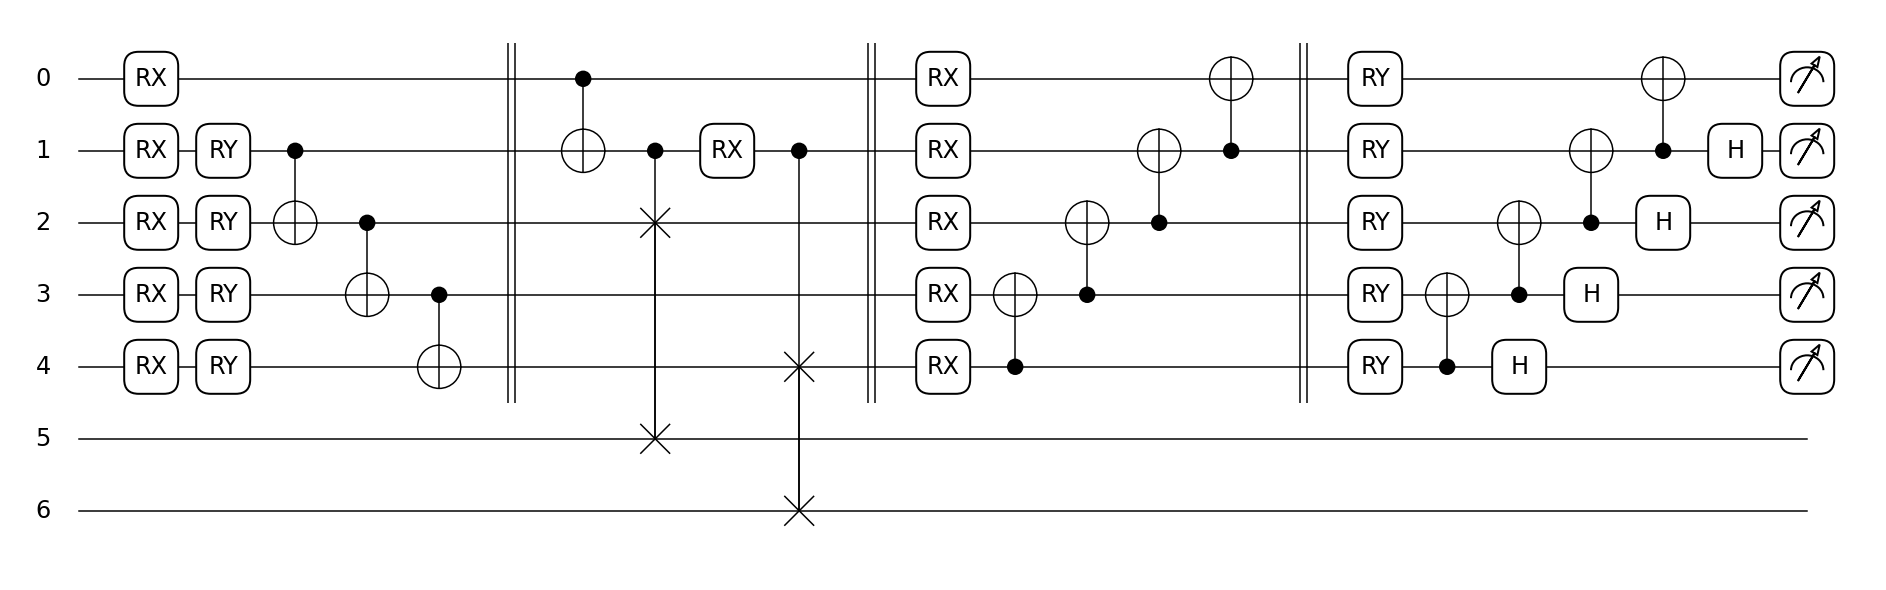

In [3]:
# https://pennylane.readthedocs.io/en/stable/code/api/pennylane.draw_mpl.html

qml.drawer.use_style('black_white')
dev = qml.device("default.qubit", wires=8)
qcirc = QGRUCirc()
qnode = qml.QNode(qcirc, dev)

fig, _ = qml.draw_mpl(qnode, fontsize=24)(torch.cat((torch.tensor([1]),torch.rand(10)),0),range(29))

In [4]:
#class QNode(func, device, interface='autograd', diff_method='best', mutable=True,
#max_expansion=10, h=1e-07, order=1, shift=1.5707963267948966, adjoint_cache=True, argnum=None, **kwargs)

class QGRU(nn.Module):
    def __init__(self):
        super(QGRU, self).__init__()
        
        dev = qml.device("default.qubit", wires=7)
        circuit = QGRUCirc()
        qnode = qml.QNode(circuit, dev)
        
        self.weight_shapes = {"weights": 29}
        self.qgru = qml.qnn.TorchLayer(qnode, self.weight_shapes)
        self.hidden_size = 4*2
                
    def forward(self, inputs, hiddens=None):
        # Currently, input dim=1, hidden dim=4x2
        in_dim = 1
        
        single = len(inputs.size()) == 1
        if single:
            inputs = torch.unsqueeze(inputs, 0)
        
#         if len(inputs.size()) == 1:
#             if hiddens == None:
#                 hiddens = torch.zeros(self.hidden_size)
#             Xs1 = torch.cat((torch.zeros(1), inputs, hiddens))
#             Xs2 = torch.cat((torch.ones(1), inputs, hiddens))
#         else:
            
            
        if hiddens == None:
            hiddens = torch.zeros([inputs.size(0), self.hidden_size])
        Xs1 = torch.cat((torch.zeros([inputs.size(0), 1]), inputs, hiddens), 1)
        Xs2 = torch.cat((torch.ones([inputs.size(0), 1]), inputs, hiddens), 1)
            
        Ys1 = self.qgru(Xs1)
        Ys2 = self.qgru(Xs2)
        
        outputs = (Ys1[:,0:in_dim] + Ys2[:,0:in_dim]) / 2
        Hs1 = Ys1[:, in_dim:]
        Hs2 = Ys2[:, in_dim:]
        
        Ys = torch.cat((outputs, Hs1, Hs2), 1)
        
        if single:
            Ys = Ys[0]
            
        return Ys # Currently, output dim=5
    

## Sequence (to make a RNN)

In [5]:
class Sequence(nn.Module):
    def __init__(self, initial_weight=None):
        super(Sequence, self).__init__()
        
        self.qgru = QGRU()
        self.out_size = 1
#         self.h_0 = torch.zeros(self.qgru.num_of_hidden)

    def forward(self, inputs, future = 0):
        # inputs: tensor
        # [[a1, a2, a3, ...]...] or [[[a1, a2, a3, ...]...]...]
        
        single = len(inputs.size()) == 2
        
        if single:
            inputs = torch.unsqueeze(inputs, 0)
        
        ht = None
        outSeq = torch.tensor([])
        
        for Xs in torch.transpose(inputs, 0, 1):
            Ys = self.qgru(Xs, ht)
            outs = Ys[:, :self.out_size]
            ht = Ys[:, self.out_size:]
            outSeq = torch.cat((outSeq, torch.unsqueeze(outs, 1)), 1)
            
        # future: only for the same types of input and output
        # the last outputs are used fot next inputs
        for _ in range(future):
            Ys = self.qgru(outs, ht)
            outs = Ys[:, :self.out_size]
            ht = Ys[:, self.out_size:]
            outSeq = torch.cat((outSeq, torch.unsqueeze(outs, 1)), 1)
            
        if single:
            outSeq = outSeq[0]
            
        return outSeq
   

## Sine

In [ ]:
sine = ((torch.tensor([np.sin(_*0.4) for _ in range(151)])*0.5)).float()
sineInput = sine[:-51]
sineTarget = sine[1:len(sineInput)+1]

sineInput = sineInput.reshape([len(sineInput),1])
sineTarget = sineTarget.reshape([len(sineTarget),1])

sineInput_a = sine[:-1]
sineInput_a = sineInput_a.reshape([len(sineInput_a),1])

plt.scatter(range(len(sine)), sine, s=3)
plt.ylim(-1,1)
plt.show()

In [ ]:
np.random.seed(0)
torch.manual_seed(0)
model = Sequence()

start_time = time.time()
criterion = torch.nn.MSELoss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
minLoss = 100000
lossList = []

for t in range(1000):
    prediction = model.forward(sineInput)
    
    # Compute and print loss
    loss = criterion(prediction, sineTarget)
    if loss.item() <= minLoss:
        minLoss = loss.item()
        best_state = copy.deepcopy(model.state_dict())

    curtime = time.time()
    print('{}: {}  {}       '.format(t, loss.item(), curtime-start_time), end='\r')
    if t % 10 == 9:
        print('{}: {}  {}       '.format(t, loss.item(), curtime-start_time))
        lossList.append(loss.item())

    # Zero gradients, perform a backward pass, and update the weights.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [ ]:
plt.plot([x*10 for x in range(len(lossList))], lossList)
plt.ylabel('Loss')
plt.xlabel('Step')
plt.yscale("log")
plt.show()

In [ ]:
best_model = Sequence()
best_model.load_state_dict(best_state)
bestPredict = best_model(sineInput, 50).detach()

In [ ]:
bp = bestPredict.tolist()
ta = sineTarget.tolist()
tb = sine[len(sineInput)+1:].tolist()
plt.scatter(range(len(ta)), ta, c='b', s=3)
plt.scatter(np.array(range(len(tb)))+len(ta), tb, c='r', s=3)
plt.plot(bp, c='g')
plt.ylim(-1,1)
plt.show()

## Damping

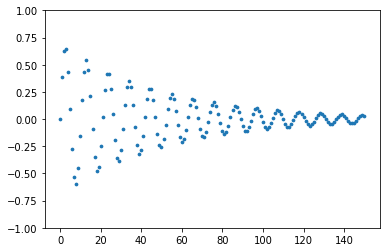

In [6]:
damp = ((torch.tensor([np.sin(_*0.6)*np.exp(_*-0.02) for _ in range(151)])*0.7)).float()
dampInput = damp[:-51]
dampTarget = damp[1:len(dampInput)+1]

dampInput = dampInput.reshape([len(dampInput),1])
dampTarget = dampTarget.reshape([len(dampTarget),1])

dampInput_a = damp[:-1]
dampInput_a = dampInput_a.reshape([len(dampInput_a),1])

plt.scatter(range(len(damp)), damp, s=3)
plt.ylim(-1,1)
plt.show()

In [18]:
np.random.seed(3)
torch.manual_seed(3)
model = Sequence()

start_time = time.time()
criterion = torch.nn.MSELoss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
minLoss = 100000
lossList = []

for t in range(1000):
    prediction = model.forward(dampInput)
    
    # Compute and print loss
    loss = criterion(prediction, dampTarget)
    if loss.item() <= minLoss:
        minLoss = loss.item()
        best_state = copy.deepcopy(model.state_dict())

    curtime = time.time()
    print('{}: {}  {}       '.format(t, loss.item(), curtime-start_time), end='\r')
    if t % 10 == 9:
        print('{}: {}  {}       '.format(t, loss.item(), curtime-start_time))
        lossList.append(loss.item())

    # Zero gradients, perform a backward pass, and update the weights.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

9: 0.04726434126496315  54.10765600204468        
19: 0.02633434534072876  112.48673510551453        
29: 0.015922019258141518  165.95920872688293       
39: 0.010077825747430325  218.7038516998291        
49: 0.007491386961191893  274.9745206832886        
59: 0.00790571328252554  331.5067412853241         
69: 0.006189283914864063  386.4096646308899        
79: 0.005342414602637291  440.62401700019836        
89: 0.004213095176964998  496.1633503437042         
99: 0.0033206334337592125  556.4068467617035        
109: 0.003942710347473621  651.1237268447876       
119: 0.004215108696371317  708.1081962585449        
129: 0.002723781391978264  764.3593072891235        
139: 0.004286392126232386  822.7811272144318        
149: 0.003117665881291032  889.9269165992737        
159: 0.0023687221109867096  946.1060466766357       
169: 0.0018815782386809587  1005.5803287029266       
179: 0.0027470767963677645  1066.5711011886597       
189: 0.0024385377764701843  1594.4693095684052       


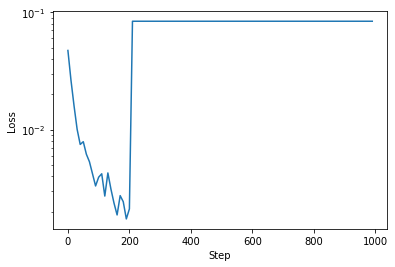

In [19]:
plt.plot([x*10 for x in range(len(lossList))], lossList)
plt.ylabel('Loss')
plt.xlabel('Step')
plt.yscale("log")
plt.show()

In [20]:
best_model = Sequence()
best_model.load_state_dict(best_state)
bestPredict = best_model(dampInput, 50).detach()

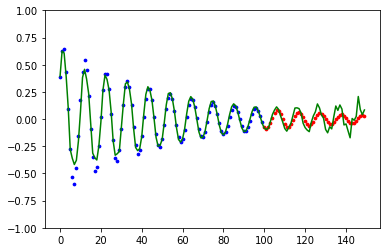

In [21]:
bp = bestPredict.tolist()
ta = dampTarget.tolist()
tb = damp[len(dampInput)+1:].tolist()
plt.scatter(range(len(ta)), ta, c='b', s=3)
plt.scatter(np.array(range(len(tb)))+len(ta), tb, c='r', s=3)
plt.plot(bp, c='g')
plt.ylim(-1,1)
plt.show()

In [31]:
criterion(bestPredict[101:], damp[101:]).item()

C:\ProgramData\Anaconda3\lib\site-packages\torch\nn\modules\loss.py:536: UserWarning: Using a target size (torch.Size([50])) that is different to the input size (torch.Size([49, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


0.02910248190164566

In [29]:
damp[101:]

tensor([-0.0733, -0.0909, -0.0766, -0.0366,  0.0143,  0.0584,  0.0807,  0.0744,
         0.0429, -0.0021, -0.0446, -0.0701, -0.0707, -0.0469, -0.0081,  0.0321,
         0.0596,  0.0657,  0.0490,  0.0161, -0.0210, -0.0494, -0.0598, -0.0493,
        -0.0223,  0.0113,  0.0397,  0.0533,  0.0482,  0.0267, -0.0031, -0.0306,
        -0.0466, -0.0460, -0.0296, -0.0037,  0.0224,  0.0399,  0.0430,  0.0312,
         0.0092, -0.0151, -0.0332, -0.0393, -0.0317, -0.0135,  0.0086,  0.0269,
         0.0352,  0.0312])

In [30]:
bestPredict[101:]

tensor([[-0.1260],
        [-0.1053],
        [-0.0494],
        [ 0.0300],
        [ 0.1125],
        [ 0.1666],
        [ 0.1601],
        [ 0.0790],
        [-0.0489],
        [-0.1535],
        [-0.1923],
        [-0.1683],
        [-0.0982],
        [ 0.0050],
        [ 0.1222],
        [ 0.2142],
        [ 0.2354],
        [ 0.1592],
        [-0.0010],
        [-0.1552],
        [-0.2227],
        [-0.2116],
        [-0.1455],
        [-0.0427],
        [ 0.0851],
        [ 0.2035],
        [ 0.2617],
        [ 0.2226],
        [ 0.0798],
        [-0.1050],
        [-0.2148],
        [-0.2331],
        [-0.1836],
        [-0.0932],
        [ 0.0291],
        [ 0.1601],
        [ 0.2520],
        [ 0.2576],
        [ 0.1567],
        [-0.0270],
        [-0.1819],
        [-0.2366],
        [-0.2127],
        [-0.1378],
        [-0.0278],
        [ 0.1046],
        [ 0.2208],
        [ 0.2686],
        [ 0.2151]])

### all data

In [ ]:
allInput = torch.cat((torch.unsqueeze(sineInput, 0), torch.unsqueeze(sineInput, 0)))
allTarget = torch.cat((torch.unsqueeze(dampTarget, 0), torch.unsqueeze(dampTarget, 0)))

## Batch loader

In [ ]:
class MyDataset(Dataset):

    # data loading
    def __init__(self, xs, ys):
        self.x = xs
        self.y = ys
        self.n_samples = len(xs)

    # working for indexing
    def __getitem__(self, index):
        
        return self.x[index], self.y[index]

    # return the length of our dataset
    def __len__(self):
        
        return self.n_samples

In [ ]:
dataset = MyDataset(allInput, allTarget)
dataloader = DataLoader(dataset=dataset, batch_size=2, shuffle=True)

In [ ]:
seed = np.random.randint(1000)
seed

In [ ]:
np.random.seed(0)
torch.manual_seed(0)
model = Sequence()

start_time = time.time()
criterion = torch.nn.MSELoss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
minLoss = 100000
lossList = []

for epoch in range(500):
    loss_total = 0.0
    n = 0
    for inpSeqC, testTargetC in dataloader:
        n += 1
        
        prediction = model.forward(inpSeqC)

        # Compute and print loss
        loss = criterion(prediction, testTargetC)
        loss_total += loss.item()

        curtime = time.time()
        print('{}, {}: {}  {}       '.format(epoch, n, loss.item(), curtime-start_time), end='\r')

        # Zero gradients, perform a backward pass, and update the weights.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    loss_avg = loss_total / n # loss per batch
    if epoch % 10 == 9:
        print('{}, avg.: {}  {}       '.format(epoch, loss_avg, curtime-start_time))
        lossList.append(loss_avg)
        
    if loss_avg <= minLoss:
        minLoss = loss_avg
        best_state = copy.deepcopy(model.state_dict())

In [ ]:
plt.clf()
plt.plot([x*10 for x in range(len(lossList))], lossList)
plt.ylabel('Loss')
plt.xlabel('Step')
plt.yscale("log")
plt.show()

In [ ]:
best_model = Sequence()
best_model.load_state_dict(best_state)

In [ ]:
bestPredict = best_model(sineInput, 50).detach()

In [ ]:
bp = bestPredict.tolist()
ta = sineTarget.tolist()
tb = sine[len(sineInput)+1:].tolist()
plt.clf()
plt.scatter(range(len(ta)), ta, c='b', s=3)
plt.scatter(np.array(range(len(tb)))+len(ta), tb, c='r', s=3)
plt.plot(bp, c='g')
plt.ylim(-1,1)
plt.show()

In [7]:
seeds = [np.random.randint(0, 1000) for _ in range(10)]
seeds = [847, 288, 794, 108, 945, 471, 300, 813, 359, 445]
seeds

[847, 288, 794, 108, 945, 471, 300, 813, 359, 445]

In [8]:
def damping_test(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    model = Sequence()

    start_time = time.time()
    criterion = torch.nn.MSELoss(reduction='mean')
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    minLoss = 100000
    lossList = []

    for t in range(1000):
        prediction = model.forward(dampInput)

        # Compute and print loss
        loss = criterion(prediction, dampTarget)
        if loss.item() <= minLoss:
            minLoss = loss.item()
            best_state = copy.deepcopy(model.state_dict())

        curtime = time.time()
        print('{}: {}  {}       '.format(t, loss.item(), curtime-start_time), end='\r')
        if t % 10 == 9:
            print('{}: {}  {}       '.format(t, loss.item(), curtime-start_time))
            lossList.append(loss.item())

        # Zero gradients, perform a backward pass, and update the weights.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    return lossList, best_state

In [ ]:
aa = test(847)

In [ ]:
loss = aa[0]
bState = aa[1]

In [ ]:
plt.clf()
plt.plot([x*10 for x in range(len(loss))], loss)
plt.ylabel('Loss')
plt.xlabel('Step')
plt.yscale("log")
plt.show()

In [ ]:
best_model = Sequence()
best_model.load_state_dict(bState)
bestPredict = best_model(testInput, 50).detach()

bp = bestPredict.tolist()
ta = testTarget.tolist()
tb = ys[len(testInput)+1:].tolist()
plt.clf()
plt.scatter(range(len(ta)), ta, c='b', s=3)
plt.scatter(np.array(range(len(tb)))+len(ta), tb, c='r', s=3)
plt.plot(bp, c='g')
plt.ylim(-1,1)
plt.show()

In [9]:
def plotPNG(seed, loss, bState):
    plt.clf()
    plt.plot([x*10 for x in range(len(loss))], loss)
    plt.ylabel('Loss')
    plt.xlabel('Step')
    plt.yscale("log")
    plt.savefig('loss_' + str(seed) + '.png')
    
    best_model = Sequence()
    best_model.load_state_dict(bState)
    bestPredict = best_model(dampInput, 50).detach()
    
    bp = bestPredict.tolist()
    ta = dampTarget.tolist()
    tb = damp[len(dampInput)+1:].tolist()
    plt.clf()
    plt.scatter(range(len(ta)), ta, c='b', s=3)
    plt.scatter(np.array(range(len(tb)))+len(ta), tb, c='r', s=3)
    plt.plot(bp, c='g')
    plt.ylim(-1,1)
    plt.savefig('result_' + str(seed) + '.png')
    

seed: 847
9: 0.04113336652517319  48.67881727218628         
19: 0.0205167755484581  97.7270040512085          
29: 0.01382491085678339  147.00070238113403        
39: 0.009465440176427364  197.56195616722107       
49: 0.006969907321035862  246.71254205703735       
59: 0.005465898662805557  295.94680976867676        
69: 0.0046254657208919525  344.59724378585815       
79: 0.004986641928553581  393.4852719306946        
89: 0.003706825664266944  444.0257451534271         
99: 0.0028116556350141764  493.03026700019836       
109: 0.0017626577755436301  542.1803529262543        
119: 0.0013751391088590026  590.9234900474548       
129: 0.0011479075765237212  639.5798645019531       
139: 0.0009385477751493454  688.1419932842255       
149: 0.0023924398701637983  736.6890964508057       
159: 0.0017227797070518136  785.9906446933746       
169: 0.0010776616400107741  834.583792924881        
179: 0.00091980816796422  883.2949826717377         
189: 0.0007792186224833131  931.94715762138

9: 0.02198224700987339  46.1439847946167         
19: 0.009609135799109936  93.9183361530304        
29: 0.006328118033707142  141.39210176467896       
39: 0.006077607162296772  188.9194815158844        
49: 0.005231738090515137  236.58235001564026        
59: 0.004853763617575169  284.3398370742798        
69: 0.00447533605620265  332.1780149936676          
79: 0.004083476960659027  380.4978404045105        
89: 0.0036235081497579813  427.9382424354553        
99: 0.0035700127482414246  476.0174436569214        
109: 0.005318521987646818  523.3611493110657        
119: 0.003618780057877302  571.0855391025543        
129: 0.003180801635608077  619.1644594669342        
139: 0.0028983703814446926  666.7110497951508       
149: 0.002703902078792453  714.5051467418671        
159: 0.0026294896379113197  762.1936984062195       
169: 0.00288421381264925  809.6961922645569         
179: 0.002953261137008667  857.7548680305481        
189: 0.00269445963203907  905.5680167675018         
19

49: 0.009449589997529984  237.17651081085205       
59: 0.006595573853701353  285.06346130371094        
69: 0.005747559480369091  333.22748017311096       
79: 0.00525776157155633  380.5744879245758         
89: 0.005213596858084202  428.6571111679077        
99: 0.004763742908835411  476.36338567733765        
109: 0.003722141496837139  524.4311480522156        
119: 0.0031771096400916576  572.1011939048767       
129: 0.0030979698058217764  619.7565140724182       
139: 0.0025025145150721073  667.4198784828186       
149: 0.0028119664639234543  715.0708799362183       
159: 0.0030840421095490456  762.8089745044708       
169: 0.002670910442247987  810.7552568912506        
179: 0.0023350967094302177  858.3488771915436       
189: 0.008469793945550919  905.7649052143097        
199: 0.003724445588886738  953.2218332290649       
209: 0.002238720655441284  1001.2885930538177       
219: 0.003923805896192789  1049.091464996338         
229: 0.0046439701691269875  1096.7126638889313    

79: 0.019390065222978592  380.6706008911133        
89: 0.01801171712577343  428.34473872184753        
99: 0.017078064382076263  476.34859108924866       
109: 0.02300293743610382  523.8995409011841         
119: 0.01902296394109726  571.7279627323151        
129: 0.033428870141506195  619.093531370163        
139: 0.03211136534810066  667.0601184368134        
149: 0.03093070536851883  714.972442150116         
159: 0.018925826996564865  762.6945283412933       
169: 0.018577061593532562  810.562662601471        
179: 0.017262639477849007  858.1478984355927       
189: 0.014934300445020199  905.8532419204712       
199: 0.016324063763022423  953.4149177074432       
209: 0.014779245480895042  1000.79314661026        
219: 0.013777803629636765  1048.9240958690643       
229: 0.012786921113729477  1096.3312680721283       
239: 0.012189393863081932  1144.1895112991333       
249: 0.011890308931469917  1191.8113391399384       
259: 0.01160038448870182  1239.4886112213135        
269: 0

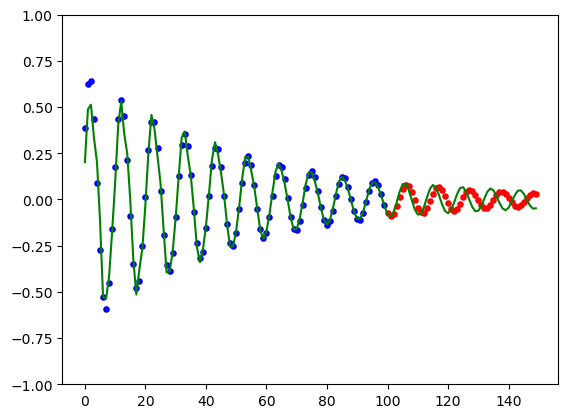

In [10]:
lossA = []
bStateA = []
for seed in seeds:
    print('seed:', seed)
    loss, bState = damping_test(seed)
    lossA.append(loss)
    bStateA.append(bState)
    
    # plot to file
    plotPNG(seed, loss, bState)

In [32]:
best_model = Sequence()
loss = 0
for bState in bStateA:
    best_model.load_state_dict(bState)
    bestPredict = best_model(dampInput, 50).detach()
    loss += criterion(bestPredict[101:], damp[101:]).item()
    
loss

0.055612502386793494

In [ ]:
seeds[6]

In [11]:
bState = bStateA[0]

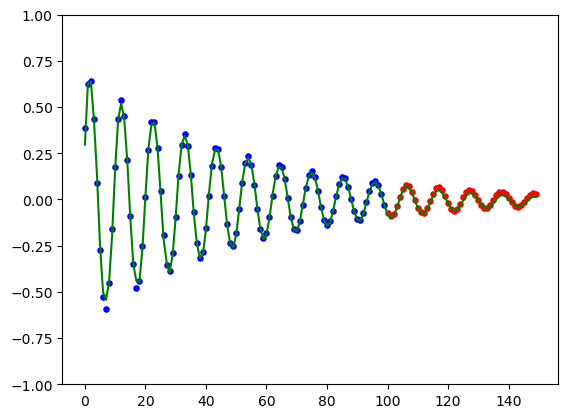

In [14]:
best_model = Sequence()
best_model.load_state_dict(bState)
bestPredict = best_model(dampInput, 50).detach()

bp = bestPredict.tolist()
ta = dampTarget.tolist()
tb = damp[len(dampInput)+1:].tolist()
plt.scatter(range(len(ta)), ta, c='b', s=3)
plt.scatter(np.array(range(len(tb)))+len(ta), tb, c='r', s=3)
plt.plot(bp, c='g')
plt.ylim(-1,1)
plt.show()

In [ ]:
# ys2 = ((torch.tensor([np.sin(_*0.5) for _ in range(151)])*0.5)).float()
ys2 = ((torch.tensor([np.sin(_*0.55)*np.exp(_*0.01) for _ in range(151)])*0.2)).float()
testInput2 = ys2[:-51]
testTarget2 = ys2[1:len(testInput)+1]

testInput2 = testInput2.reshape([len(testInput2),1])
testTarget2 = testTarget2.reshape([len(testTarget2),1])

In [ ]:
best_model = Sequence()
best_model.load_state_dict(bState)
bestPredict2 = best_model(testInput2, 50).detach()

bp2 = bestPredict2.tolist()
ta2 = testTarget2.tolist()
tb2 = ys2[len(testInput2)+1:].tolist()
plt.plot(range(len(ta2)), ta2, c='c')
plt.plot(np.array(range(len(tb2)))+len(ta2), tb2, c='pink')
plt.plot(bp2, c='g')
plt.ylim(-1,1)
plt.show()

## Save / Load

In [11]:
with open('lossA.pickle', 'wb') as f:
    pickle.dump(lossA, f)
with open('bStateA.pickle', 'wb') as f:
    pickle.dump(bStateA, f)

In [ ]:
with open('bStateA.pickle', 'rb') as f:
    bStateA = pickle.load(f)